# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1781793914921.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-06-18 10:12:37 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,TGT,$129.82,0.03851,COMPLETE,$5 Purchase of Target,NaN,Cash Balance
1,2026-06-18 10:12:13 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,ACN,$131.73,0.03795,COMPLETE,$5 Purchase of Accenture,NaN,Cash Balance
2,2026-06-18 10:11:51 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,DBX,$26.03,0.19211,COMPLETE,$5 Purchase of Dropbox,NaN,Cash Balance
3,2026-06-18 10:11:03 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,JPM,$333.15,0.01500,COMPLETE,$5 Purchase of JPMorgan Chase,NaN,Cash Balance
4,2026-06-18 10:10:46 EDT,NaN,NaN,USD,$3.00,$0.00,$3.00,SPCX,$180.60,0.01661,COMPLETE,$3 Sale of SpaceX,NaN,Cash Balance
5,2026-06-18 10:10:24 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,WFC,$83.79,0.05967,COMPLETE,$5 Purchase of Wells Fargo,NaN,Cash Balance
6,2026-06-18 10:10:06 EDT,NaN,NaN,USD,$3.00,$0.00,$3.00,EBAY,$109.56,0.02738,COMPLETE,$3 Sale of eBay,NaN,Cash Balance
7,2026-06-18 10:09:47 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,META,$572.17,0.00873,COMPLETE,$5 Purchase of Meta,NaN,Cash Balance
8,2026-06-18 10:09:21 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,WMG,$28.21,0.17722,COMPLETE,$5 Purchase of Warner Music,NaN,Cash Balance
9,2026-06-18 10:09:00 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,VOO,$687.48,0.00727,COMPLETE,$5 Purchase of Vanguard S&P 500 ETF,NaN,Cash Balance


In [3]:
data_raw[data_raw['Transaction Type'].isna()]

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
4,2026-06-18 10:10:46 EDT,NaN,NaN,USD,$3.00,$0.00,$3.00,SPCX,$180.60,0.01661,COMPLETE,$3 Sale of SpaceX,NaN,Cash Balance
6,2026-06-18 10:10:06 EDT,NaN,NaN,USD,$3.00,$0.00,$3.00,EBAY,$109.56,0.02738,COMPLETE,$3 Sale of eBay,NaN,Cash Balance
19,2026-06-16 11:47:45 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,UHAL,$62.78,0.15928,COMPLETE,$10 Sale of U-Haul,NaN,Cash Balance
20,2026-06-16 11:47:18 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,UBER,$74.07,0.26999,COMPLETE,$20 Sale of Uber Technologies,NaN,Cash Balance
23,2026-06-16 11:45:45 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$868.45,0.01151,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
53,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
61,2026-06-16 09:30:05 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,HOOD,$100.19,0.04990,COMPLETE,$5 Sale of Robinhood Markets,NaN,Cash Balance
110,2026-06-08 12:38:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,JPM,$312.37,0.06402,COMPLETE,$20 Sale of JPMorgan Chase,NaN,Cash Balance
112,2026-06-08 12:37:07 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,HOOD,$85.17,0.05870,COMPLETE,$5 Sale of Robinhood Markets,NaN,Cash Balance
118,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance


In [4]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.03851
1      0.03795
2      0.19211
3      0.01500
4      0.01661
        ...   
520        NaN
521        NaN
522        NaN
523        NaN
524        NaN
Name: Asset Amount, Length: 525, dtype: float64

In [5]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE)

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
249,2026-06-03 15:12:01+00:00,-10.00,-10.00,432.10,0.023140,0.0,TSLA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Tesla,NaN
406,2026-06-01 13:30:12+00:00,-10.00,-10.00,270.00,0.037030,0.0,ADBE,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Adobe,NaN
470,2026-05-28 20:45:28+00:00,-50.00,-50.00,NaN,0.000000,0.0,NaN,Savings Internal Transfer,USD,NaN,Cash Balance,COMPLETE,Savings,NaN
480,2026-05-27 13:33:12+00:00,-5.00,-5.00,77.41,0.064590,0.0,WFC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Wells Fargo,NaN
242,2026-06-03 15:16:53+00:00,19.99,19.99,967.22,0.020670,0.0,LITE,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$19.99 Sale of Lumentum,NaN
343,2026-06-03 13:04:41+00:00,0.00,0.00,NaN,0.000000,NaN,NaN,Account Notifications,USD,NaN,Cash Balance,COMPLETE,New device login,NaN
355,2026-06-02 18:10:49+00:00,100.00,100.00,NaN,0.000000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
392,2026-06-01 13:30:21+00:00,-10.00,-10.00,860.16,0.011620,0.0,CAT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Caterpillar,NaN
515,2026-05-26 14:06:39+00:00,-10.00,-9.80,77672.17,0.000126,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00012617,NaN
403,2026-06-01 13:30:15+00:00,-25.00,-25.00,34.25,0.729920,0.0,DOW,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Dow,NaN


In [6]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,525.000000,525.000000,437.000000,525.000000,522.000000
mean,-0.195486,-0.185505,4114.641030,0.129544,-0.010038
std,41.354026,41.351101,16343.100006,0.244400,0.055559
min,-400.000000,-400.000000,5.130000,0.000000,-0.500000
25%,-10.000000,-10.000000,56.850000,0.011620,0.000000
50%,-10.000000,-10.000000,131.730000,0.045710,0.000000
75%,-5.000000,-5.000000,301.750000,0.131060,0.000000
max,200.000000,200.000000,80346.140000,2.378910,0.000000


In [7]:
data.nunique().sort_values(ascending=False)

asset_price     432
asset_amount    429
date            413
notes           310
asset_type      163
amount           40
net_amount       38
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [8]:
data['asset_type'].value_counts()

asset_type
BTC     24
JPM     11
XYZ     11
WFC      9
META     9
        ..
AVGO     1
VBR      1
SBUX     1
TSM      1
NVDA     1
Name: count, Length: 163, dtype: int64

In [9]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,24,-197.36,"(-24.5, -9.8, -4.9, -0.98, 5.0, 20.0)",6
JPM,11,-80.00,"(-25.0, -10.0, -5.0, 20.0)",4
XYZ,11,-171.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0)",6
V,9,-101.00,"(-25.0, -20.0, -10.0, -5.0, -1.0)",5
MCD,9,-89.80,"(-25.0, -10.0, -5.0, 0.2)",4
META,9,-71.00,"(-10.0, -5.0, -1.0)",3
WFC,9,-81.00,"(-25.0, -10.0, -5.0, -1.0)",4
ORCL,9,-75.00,"(-10.0, -5.0)",2
UBER,8,-91.00,"(-50.0, -25.0, -10.0, -5.0, -1.0, 20.0)",6


In [10]:
data['currency'].value_counts()

currency
USD    525
Name: count, dtype: int64

In [11]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    397
Deposits                      60
Bitcoin Buy                   21
Stock Sell                    16
Savings Internal Transfer     12
Stock Dividends                6
P2P                            6
Bitcoin Sell                   3
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [12]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,21,3,397,6,16,443
BTC,21,3,0,0,0,24
XYZ,0,0,11,0,0,11
JPM,0,0,10,0,1,11
ORCL,0,0,9,0,0,9
WFC,0,0,9,0,0,9
V,0,0,9,0,0,9
MCD,0,0,8,1,0,9
META,0,0,9,0,0,9


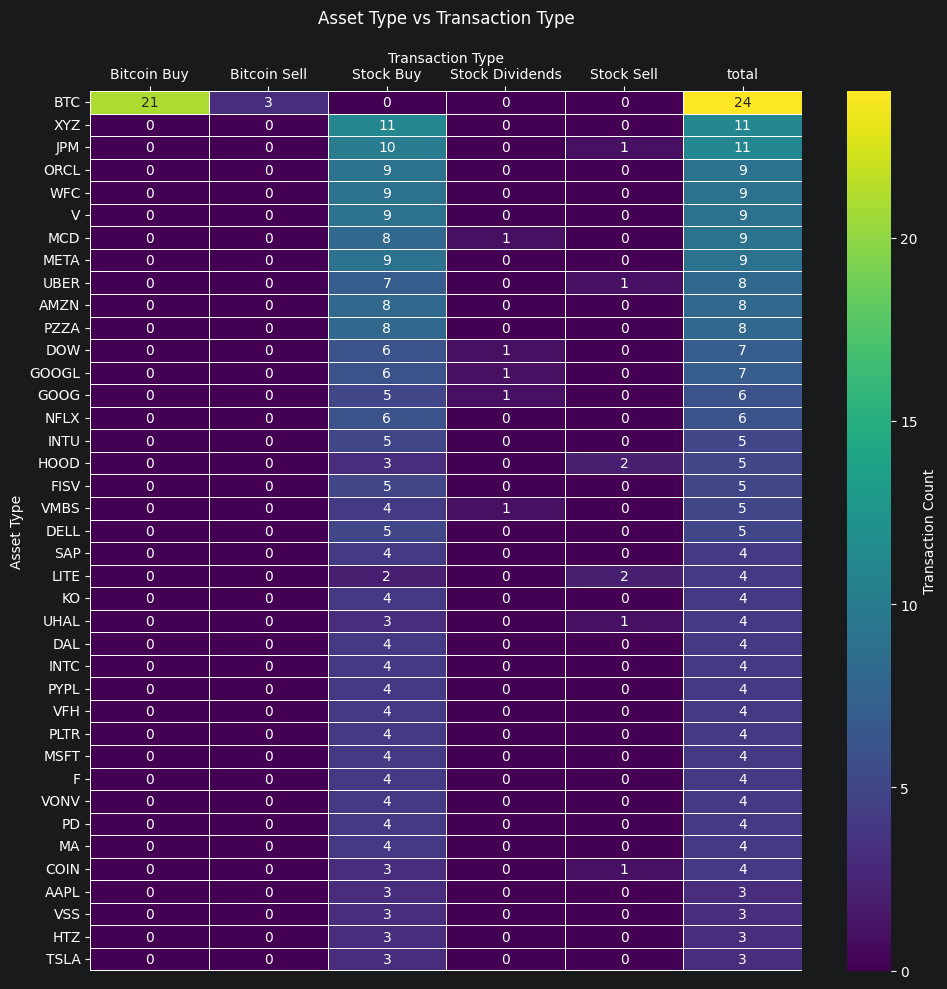

In [13]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,

)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [14]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
73,2026-06-16 12:39:28+00:00,4.9,5.00,66069.72,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007568,NaN
74,2026-06-16 12:03:53+00:00,4.9,5.00,65883.50,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007589,NaN
77,2026-06-16 01:27:11+00:00,-5.0,-4.90,66797.17,0.000073,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
113,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
193,2026-06-03 19:29:17+00:00,-10.0,-9.80,66010.01,0.000148,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014846,NaN
220,2026-06-03 16:16:50+00:00,-10.0,-9.80,66582.56,0.000147,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014719,NaN
244,2026-06-03 15:14:44+00:00,-1.0,-0.98,66904.02,0.000015,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001465,NaN
341,2026-06-03 13:08:30+00:00,-10.0,-9.80,67420.34,0.000145,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014536,NaN
352,2026-06-02 19:54:00+00:00,-1.0,-0.98,67817.91,0.000014,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001445,NaN
369,2026-06-01 14:38:57+00:00,-10.0,-9.80,71929.33,0.000136,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00013624,NaN


<Axes: xlabel='date'>

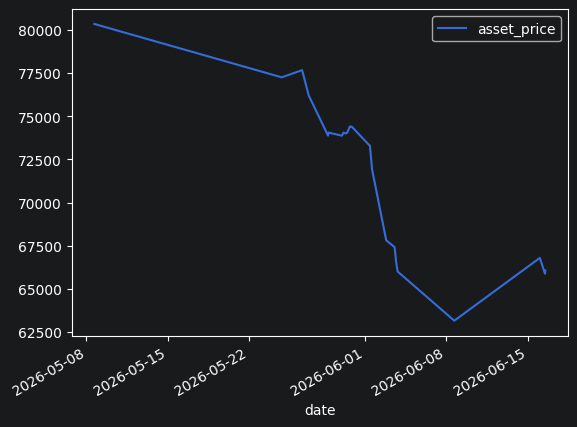

In [15]:
data_btc.plot.line(x='date', y='asset_price')

In [16]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     21
Bitcoin Sell     3
Name: count, dtype: int64

In [17]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-232.0
Bitcoin Sell,29.4


In [18]:
data_btc['net_amount'].sum()

np.float64(-202.6)

In [19]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003100
Bitcoin Sell    0.000468
Name: asset_amount, dtype: float64

In [20]:
data_btc['asset_amount'].sum()

np.float64(0.0035680600000000005)

In [21]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00263162)

Text(0, 0.5, 'BTC Price')

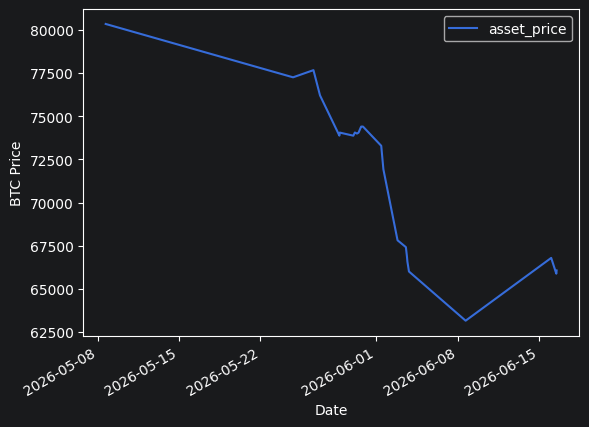

In [22]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')

Text(0, 0.5, 'Holdings BTC')

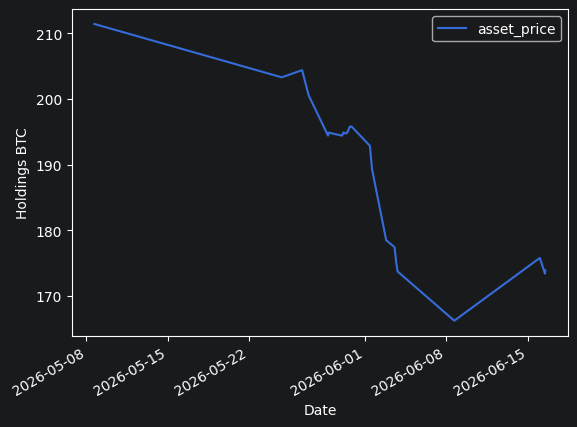

In [23]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')

In [24]:
data_btc['asset_price'] * data_btc['asset_amount']

73      5.000156
74      4.999899
77      4.900240
113    19.999798
193     9.799846
220     9.800287
244     0.980144
341     9.800221
352     0.979969
369     9.799652
427     4.900136
429     9.799865
432     4.900112
433     9.799903
437     9.799965
441    24.500200
448    24.499951
452    24.500084
471     9.799731
475     9.800031
498    24.499991
515     9.799898
516     4.900356
517     9.799819
dtype: float64

In [25]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
35,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
80,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
128,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
204,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
216,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
229,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
267,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
270,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
373,2026-06-01 13:30:51+00:00,-25.0,-25.0,77.50,0.32258,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Block,NaN
458,2026-05-29 13:33:18+00:00,-50.0,-50.0,75.00,0.66666,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$50 Purchase of Block,NaN


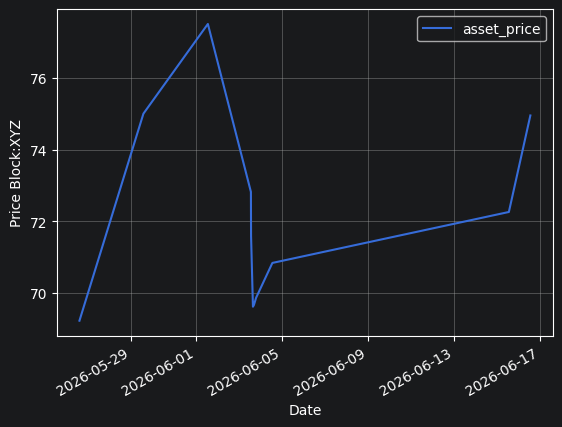

In [26]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [27]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     24
JPM     11
XYZ     11
V        9
MCD      9
        ..
HPQ      1
HMC      1
HLF      1
HIMS     1
ZG       1
Name: amount, Length: 163, dtype: int64

In [28]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [29]:
data['asset_amount'].describe()

count    525.000000
mean       0.129544
std        0.244400
min        0.000000
25%        0.011620
50%        0.045710
75%        0.131060
max        2.378910
Name: asset_amount, dtype: float64

In [30]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 19:31:42+00:00,20.147721,9.999493,9.010079,9.9981,20.098273,9.999577,19.549552,0.000000,9.998423,0.000000,...,19.705162,51.890247,18.724670,29.991989,9.999899,131.892037,19.945984,9.99999,0.000000,0.000000
2026-06-08 16:33:33+00:00,20.147721,9.999493,9.010079,9.9981,20.098273,9.999577,19.549552,9.999998,9.998423,19.996016,...,19.705162,77.322328,18.724670,29.991989,9.999899,154.936279,29.944329,9.99999,9.999727,9.999925
2026-06-18 14:06:52+00:00,30.146473,9.999493,11.181242,9.9981,20.098273,9.999577,19.549552,9.999998,9.998423,19.996016,...,19.705162,81.303113,18.724670,29.991989,9.999899,176.075538,29.944329,9.99999,9.999727,9.999925
2026-06-01 13:30:04+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,9.549584,0.000000,0.000000,0.000000,...,0.000000,4.945656,0.000000,9.555644,0.000000,74.055125,0.000000,0.00000,0.000000,0.000000
2026-06-10 13:35:01+00:00,30.146473,9.999493,9.010079,9.9981,20.098273,9.999577,19.549552,9.999998,9.998423,19.996016,...,19.705162,77.322328,18.724670,29.991989,9.999899,154.936279,29.944329,9.99999,9.999727,9.999925
2026-06-01 13:30:16+00:00,0.000000,0.000000,0.000000,9.9981,0.000000,0.000000,9.549584,0.000000,0.000000,0.000000,...,9.706497,4.945656,0.000000,9.555644,0.000000,74.055125,0.000000,0.00000,0.000000,0.000000
2026-06-03 16:16:50+00:00,20.147721,9.999493,9.010079,9.9981,20.098273,9.999577,19.549552,0.000000,9.998423,0.000000,...,19.705162,41.665912,9.686363,29.991989,9.999899,109.742791,19.945984,9.99999,0.000000,0.000000
2026-06-10 13:30:05+00:00,30.146473,9.999493,9.010079,9.9981,20.098273,9.999577,19.549552,9.999998,9.998423,19.996016,...,19.705162,77.322328,18.724670,29.991989,9.999899,154.936279,29.944329,9.99999,9.999727,9.999925
2026-06-03 15:14:44+00:00,20.147721,9.999493,9.010079,9.9981,20.098273,0.000000,19.549552,0.000000,9.998423,0.000000,...,19.705162,41.665912,9.686363,29.991989,9.999899,99.663815,0.000000,9.99999,0.000000,0.000000


In [31]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3875.8092429)

In [32]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-18 14:10:46+00:00,0.007778,0.00258,0.002885,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:11:03+00:00,0.007778,0.00258,0.002885,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:11:51+00:00,0.007778,0.00258,0.002885,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:12:13+00:00,0.007778,0.00258,0.004175,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:12:37+00:00,0.007778,0.00258,0.004175,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258


In [33]:
asset_price_rel.iloc[-1].describe()

count    163.000000
mean       0.006135
std        0.006167
min        0.000000
25%        0.002580
50%        0.005077
75%        0.006910
max        0.045429
Name: 2026-06-18 14:12:37+00:00, dtype: float64

In [34]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.045429
AMZN    0.034648
V       0.026878
DELL    0.026521
UBER    0.024812
Name: 2026-06-18 14:12:37+00:00, dtype: float64

In [35]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-18 14:10:46+00:00,0.007778,0.00258,0.002885,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:11:03+00:00,0.007778,0.00258,0.002885,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:11:51+00:00,0.007778,0.00258,0.002885,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:12:13+00:00,0.007778,0.00258,0.004175,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258
2026-06-18 14:12:37+00:00,0.007778,0.00258,0.004175,0.00258,0.005186,0.00258,0.005044,0.00258,0.00258,0.005159,...,0.005084,0.022267,0.006121,0.007738,0.00258,0.045429,0.007726,0.00258,0.00258,0.00258


In [36]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 15:43:17+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:33:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:33:39+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:28+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:36:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 13:33:18+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,75.0,NaN,NaN,NaN,NaN
2026-06-08 13:30:13+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:43:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 16:52:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 15:43:17+00:00,1.018386,1.0,0.901125,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.0,1.0,1.0
2026-05-27 13:33:02+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
2026-06-03 13:33:39+00:00,1.021803,1.0,1.000000,1.0,1.00,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.016277,1.000000,0.955619,1.0,1.119457,1.000000,1.0,1.0,1.0
2026-06-15 13:30:28+00:00,1.018386,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.0,1.0,1.0
2026-06-03 19:36:21+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.016406,0.968648,0.976969,1.0,1.009245,1.000000,1.0,1.0,1.0
2026-05-29 13:33:18+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.0,1.0,1.0
2026-06-08 13:30:13+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.0,1.0,1.0
2026-06-03 19:43:16+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.0,1.0,1.0
2026-06-02 16:52:54+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.0,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

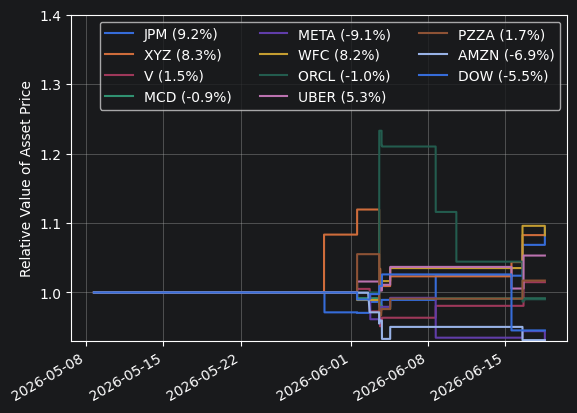

In [38]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [39]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-06-18 14:10:46+00:00    1.082623
2026-06-18 14:11:03+00:00    1.082623
2026-06-18 14:11:51+00:00    1.082623
2026-06-18 14:12:13+00:00    1.082623
2026-06-18 14:12:37+00:00    1.082623
Name: XYZ, Length: 326, dtype: float64

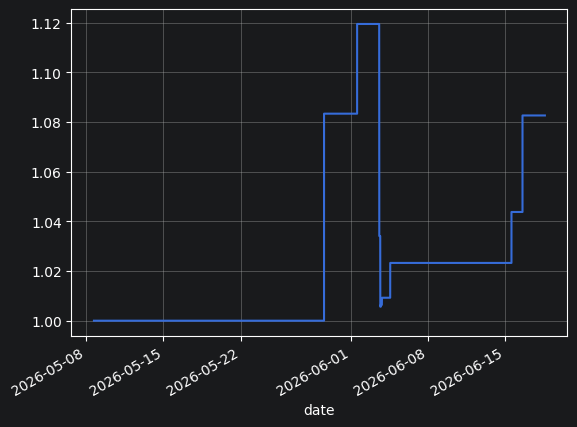

In [40]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [41]:
(data[data['trans_type'] == 'Stock Dividends']
 .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status', 'trans_type', 'net_amount'])
 )

,date,amount,asset_type,notes
13,2026-06-18 04:00:00+00:00,0.07,HD,$0.07 Dividend from Home Depot
75,2026-06-16 04:00:00+00:00,0.20,MCD,$0.20 Dividend from McDonald's
93,2026-06-15 04:00:00+00:00,0.02,GOOG,$0.02 Dividend from Alphabet Inc. Class C
94,2026-06-15 04:00:00+00:00,0.02,GOOGL,$0.02 Dividend from Alphabet Inc. Class A
97,2026-06-12 04:00:00+00:00,0.05,DOW,$0.05 Dividend from Dow
350,2026-06-03 04:00:00+00:00,0.03,VMBS,$0.03 Dividend from Vanguard Mortgage-Backed S...


In [42]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
402,2026-06-01 13:30:15+00:00,-10.0,104.12,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
309,2026-06-03 13:30:09+00:00,-10.0,272.44,$10 Purchase of Vanguard Health Care ETF,VHT
388,2026-06-01 13:30:23+00:00,-25.0,95.08,$25 Purchase of Vanguard Real Estate ETF,VNQ
30,2026-06-16 15:42:33+00:00,-5.0,55.01,$5 Purchase of Vanguard Long-Treasury ETF,VGLT
89,2026-06-15 13:30:12+00:00,-10.0,231.00,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
295,2026-06-03 13:30:12+00:00,-1.0,46.56,$1 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
12,2026-06-18 14:06:52+00:00,-5.0,50.45,$5 Purchase of Vanguard Tax-Exempt Bond ETF,VTEB
64,2026-06-16 13:30:05+00:00,-5.0,98.42,$5 Purchase of Vanguard Real Estate ETF,VNQ
224,2026-06-03 15:53:29+00:00,-10.0,54.44,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
9,2026-06-18 14:09:00+00:00,-5.0,687.48,$5 Purchase of Vanguard S&P 500 ETF,VOO


In [43]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VMBS    5
VONV    4
VFH     4
VOO     3
VDE     3
VHT     3
VSS     3
VTEB    2
VGLT    2
VNQ     2
VDC     2
BNDX    2
VCR     2
VONG    1
BIV     1
VBR     1
Name: count, dtype: int64

In [44]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
402,2026-06-01 13:30:15+00:00,-10.0,104.12,VONV,Vanguard Russell 1000 Value ETF
309,2026-06-03 13:30:09+00:00,-10.0,272.44,VHT,Vanguard Health Care ETF
388,2026-06-01 13:30:23+00:00,-25.0,95.08,VNQ,Vanguard Real Estate ETF
30,2026-06-16 15:42:33+00:00,-5.0,55.01,VGLT,Vanguard Long-Treasury ETF
89,2026-06-15 13:30:12+00:00,-10.0,231.00,VDC,Vanguard Consumer Staples Index Fund ETF
295,2026-06-03 13:30:12+00:00,-1.0,46.56,VMBS,Vanguard Mortgage-Backed Securities ETF
12,2026-06-18 14:06:52+00:00,-5.0,50.45,VTEB,Vanguard Tax-Exempt Bond ETF
64,2026-06-16 13:30:05+00:00,-5.0,98.42,VNQ,Vanguard Real Estate ETF
224,2026-06-03 15:53:29+00:00,-10.0,54.44,VGLT,Vanguard Long-Treasury ETF
9,2026-06-18 14:09:00+00:00,-5.0,687.48,VOO,Vanguard S&P 500 ETF


In [45]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VFH         Vanguard Financials ETF                        4
VMBS        Vanguard Mortgage-Backed Securities ETF        4
VONV        Vanguard Russell 1000 Value ETF                4
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
VOO         Vanguard S&P 500 ETF                           3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
BNDX        Vanguard Total International Bond ETF          2
VCR         Vanguard Consumer Discretionary ETF            2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGLT        Vanguard Long-Treasury ETF                     2
VNQ         Vanguard Real Estate ETF                       2
VTEB        Vanguard Tax-Exempt Bond ETF                   2
BIV         Vanguard Intermediate Term Bond ETF            1
VBR         Small Cap Value ETF Vanguard                   1
VONG        Vanguard Russell 

In [46]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VMBS,VONV,VFH,VOO,VDE,VHT,VSS,VTEB,VGLT,VNQ,VDC,BNDX,VCR,VONG,BIV,VBR
date,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,NaN,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
vanguard_trans_count

asset_type
VMBS    5
VONV    4
VFH     4
VOO     3
VDE     3
VHT     3
VSS     3
VTEB    2
VGLT    2
VNQ     2
VDC     2
BNDX    2
VCR     2
VONG    1
BIV     1
VBR     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

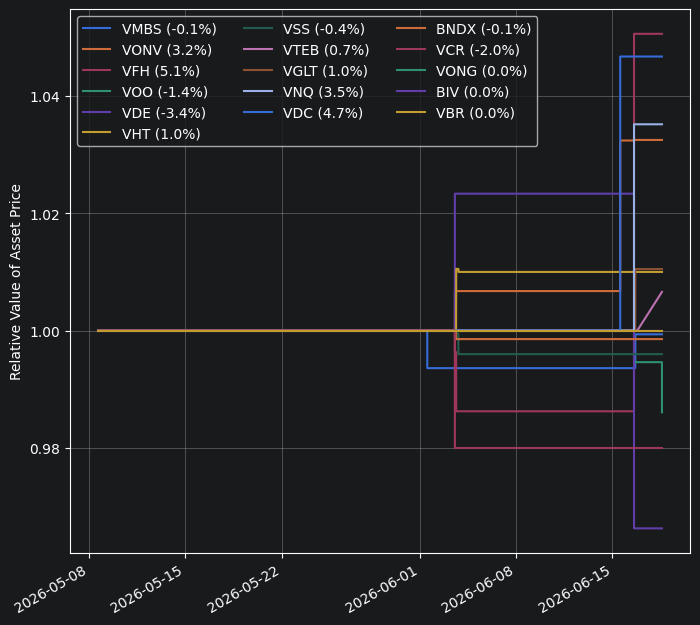

In [48]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')